In [1]:
#from graph_transformer_long_range_niches.tl.wandb import load_and_log
from graph_transformer_long_range_niches._paths import CFG_FILES, HE22_HUMAN_LUNG_DATA_PATH
from graph_transformer_long_range_niches.model.gnn_transformer import LitGNNTransformer
from graph_transformer_long_range_niches.modules.gcn import LitGCN
from graph_transformer_long_range_niches.tl.utils import pad_batch
from graph_transformer_long_range_niches.tl.evaluation import eval_gnntransformer, extract_attention
from graph_transformer_long_range_niches.pl.color_map import CustomColormap
from graph_transformer_long_range_niches.pp.geome_utils import prepare_geome_dataset
from graph_transformer_long_range_niches.config import load_config
from graph_transformer_long_range_niches.pl.attention_matrix import plot_attention_sender_receiver

import warnings
warnings.filterwarnings("ignore")

from torch_geometric.loader import DataLoader

from pathlib import Path
import wandb
import torch
import os

## plotting
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

import scanpy as sc
import squidpy as sq

import pickle

# Load model checkpoint and data

In [1]:
cfg_trans = load_config(Path(CFG_FILES, 'pancreas_gnntrans_genes.yaml'))
cfg_gnn = load_config(Path(CFG_FILES, 'pancreas_gnn_genes.yaml'))

NameError: name 'load_config' is not defined

In [3]:
data_gnntrans = f"{cfg_trans.dataset.name}_{cfg_trans.dataset.prediction_obs}_{cfg_trans.dataset.library_key}_{cfg_trans.optim.seed}"
run_gnntrans = f"{data_gnntrans}_{cfg_trans.model.model_type}"
print(data_gnntrans)
print(run_gnntrans)
data_gnn = f"{cfg_gnn.dataset.name}_{cfg_gnn.dataset.prediction_obs}_{cfg_gnn.dataset.library_key}_{cfg_gnn.optim.seed}"
run_gnn = f"{data_gnn}_{cfg_gnn.model.model_type}"
print(data_gnn)
print(run_gnn)

pancreas_condition_sliding_window_40
pancreas_condition_sliding_window_40_gnn-transformer
pancreas_condition_sliding_window_42
pancreas_condition_sliding_window_42_gnn


In [4]:
checkpoint = torch.load(Path(cfg_trans.model.output_path, f"{run_gnntrans}.ckpt"))
model_transformer = LitGNNTransformer(checkpoint['hyper_parameters']['cfg'])
model_transformer.load_state_dict(checkpoint['state_dict'])

num features: 979


<All keys matched successfully>

In [5]:
checkpoint_gnn = torch.load(Path(cfg_gnn.model.output_path, f"{run_gnn}.ckpt"))
model_gnn = LitGCN(checkpoint_gnn['hyper_parameters']['cfg'])
model_gnn.load_state_dict(checkpoint_gnn['state_dict'])

<All keys matched successfully>

In [6]:
adata = sc.read_h5ad(Path(cfg_trans.model.output_path, f"{data_gnntrans}.h5ad"))
adata

AnnData object with n_obs × n_vars = 108711 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'x', 'y', 'sliding_window', 'split'
    var: 'NegPrb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p', 'spatial'
    obsm: 'spatial', 'spatial_fov'
    layers: 'counts'

In [7]:
with open(Path(cfg_trans.model.output_path, f"{data_gnntrans}.pkl"), 'rb') as f:
    pyg_data = pickle.load(f)
train_pyg = pyg_data[0]
val_pyg = pyg_data[1]
print('train: ', len(train_pyg), 'val: ', len(val_pyg))

train:  114 val:  30


In [8]:
train_adata = adata[adata.obs['split'] == 'train']
val_adata = adata[adata.obs['split'] == 'val']

In [9]:
print(np.unique(train_adata.obs['fov']))
print(np.unique(val_adata.obs['fov']))

['1' '10' '11' '12' '13' '14' '17' '18' '19' '2' '20' '21' '22' '23' '4'
 '5' '6' '7' '8']
['15' '16' '24' '3' '9']


## Predict gene expression

In [10]:
eval_loader = DataLoader(val_pyg[0:1], 1)
for i, batch in enumerate(eval_loader):
    #transformer_in, transformer_out, src_padding_mask, index_nodes = eval_gnntransformer(model, batch)
    transformer_in, transformer_out, src_padding_mask, index_nodes, dec_out = model_transformer.evaluation(model_transformer, batch)
    gnn_x, gnn_z = model_gnn.evaluation(model_gnn, batch)

In [11]:
transformer_out

tensor([[[ 0.6251, -0.1546, -0.1306,  ...,  0.7246, -0.6888,  0.1222]],

        [[ 0.6295, -0.1104, -0.1087,  ...,  0.5069, -0.7476,  0.4729]],

        [[ 0.5553, -0.1458, -0.0739,  ...,  0.5774, -0.7389,  0.2009]],

        ...,

        [[ 0.4401, -0.1191, -0.0458,  ...,  0.3159, -0.5953,  0.3243]],

        [[ 0.0486, -0.1542, -0.1059,  ...,  0.6308, -0.9321,  0.0459]],

        [[ 0.1193,  0.0395,  0.1590,  ...,  0.1499, -0.0671,  0.0252]]],
       grad_fn=<NativeLayerNormBackward0>)

In [26]:
# sort gene by performance
from torchmetrics.regression import MeanSquaredError

y_true = batch.x[index_nodes]
y_pred = dec_out
y_pred_gnn = gnn_z
mean_squared_error = MeanSquaredError()
genes = adata.var_names
# Calculate MSE for each gene (column-wise MSE)
mse_per_gene = [mean_squared_error(y_pred[:, i], y_true[:, i]).item() for i in range(y_pred.shape[1])]
mse_gnn = [mean_squared_error(y_pred_gnn[:, i], batch.x[:, i]).item() for i in range(y_pred_gnn.shape[1])]
mse_df_gnntrans = pd.DataFrame({
    'Gene': genes,
    'MSE_gnntrans': mse_per_gene,
})
mse_df_gnn = pd.DataFrame({
    'Gene': genes,
    'MSE_gnn': mse_gnn
})
best_predicted_genes_gnntrans = mse_df_gnntrans.sort_values(by='MSE_gnntrans')
best_predicted_genes_gnn = mse_df_gnn.sort_values(by='MSE_gnn')


# Display the best-predicted genes
print(best_predicted_genes_gnntrans)
print(best_predicted_genes_gnn)

         Gene  MSE_gnntrans
973  NegPrb18      0.000927
229   COL21A1      0.000964
212    CLEC4D      0.001414
725       PGR      0.001842
854    SUCNR1      0.002013
..        ...           ...
739     PRSS2      0.359467
666     MZT2A      0.382102
247      CPB1      0.442789
770     REG1A      0.469975
625    MALAT1      0.584719

[979 rows x 2 columns]
         Gene   MSE_gnn
973  NegPrb18  0.000240
212    CLEC4D  0.001148
676     NLRC5  0.001434
229   COL21A1  0.001729
601     LAMP3  0.002106
..        ...       ...
446  HSP90AB1  0.597843
770     REG1A  0.625286
625    MALAT1  0.677490
835    SPINK1  0.693543
247      CPB1  0.716363

[979 rows x 2 columns]


In [13]:
# Calculate the mean expression for each gene across all samples
mean_expression_per_gene = y_true.mean(dim=0).cpu().numpy()  # Convert tensor to numpy array for pandas

# Create a DataFrame to store the gene expression for each gene
expression_df = pd.DataFrame({
    'Gene': genes,
    'MeanExpression': mean_expression_per_gene
})

# Sort by mean expression in descending order (highest expressed genes first)
sorted_genes_by_expression = expression_df.sort_values(by='MeanExpression', ascending=False)

# Display the genes sorted by their true expression values
print(sorted_genes_by_expression)

         Gene  MeanExpression
739     PRSS2        2.964937
770     REG1A        2.434697
625    MALAT1        1.799467
247      CPB1        1.764143
835    SPINK1        0.945643
..        ...             ...
551     ITGAL        0.002077
854    SUCNR1        0.001884
212    CLEC4D        0.001639
229   COL21A1        0.000869
973  NegPrb18        0.000530

[979 rows x 2 columns]


In [28]:
from scipy.stats import pearsonr


def gene_correlation(y_true, y_pred):
    # List of gene names
    genes = adata.var_names

    # Initialize a list to store correlation values
    correlation_per_gene = []

    # Calculate Pearson correlation for each gene (column-wise correlation)
    for i in range(y_true.shape[1]):  # Loop over genes
        true_values = y_true[:, i].cpu().detach().numpy()  # True expression values for gene i
        predicted_values = y_pred[:, i].cpu().detach().numpy()  # Predicted values for gene i

        # Compute Pearson correlation between true and predicted values
        correlation, _ = pearsonr(true_values, predicted_values)
        correlation_per_gene.append(correlation)

    # Create a DataFrame to store the gene names and correlation values
    correlation_df = pd.DataFrame({
        'Gene': genes,
        'Correlation': correlation_per_gene
    })

    # Sort genes by correlation (highest to lowest)
    sorted_genes_by_correlation = correlation_df.sort_values(by='Correlation', ascending=False)

    # Display the genes sorted by their correlation between true and predicted values
    print(sorted_genes_by_correlation[:20])

gene_correlation(batch.x[index_nodes], dec_out) # GNNTransformer
gene_correlation(batch.x, gnn_z) # GNN

         Gene  Correlation
540       INS     0.930844
919       TTR     0.872390
390       GCG     0.853022
739     PRSS2     0.819091
247      CPB1     0.786022
835    SPINK1     0.784422
770     REG1A     0.782815
217       CLU     0.760073
307     DUSP5     0.752253
265     CUZD1     0.749165
670     NEAT1     0.745746
625    MALAT1     0.738764
445  HSP90AA1     0.738132
666     MZT2A     0.730569
925      TYK2     0.730305
446  HSP90AB1     0.729969
812  SERPINA3     0.725701
686      NPPC     0.722201
595      KRT8     0.718295
70       AZU1     0.718260
         Gene  Correlation
540       INS     0.914843
919       TTR     0.846323
390       GCG     0.829397
739     PRSS2     0.744864
625    MALAT1     0.707649
770     REG1A     0.693096
199      CHGA     0.644689
247      CPB1     0.640554
812  SERPINA3     0.599986
670     NEAT1     0.591000
265     CUZD1     0.590868
666     MZT2A     0.576960
835    SPINK1     0.535228
50      ANXA4     0.527307
925      TYK2     0.520124
6

In [15]:
transformer_out.shape

torch.Size([1001, 1, 128])

In [16]:
trans_emb_diff = transformer_in - transformer_out[:-1]
emb_diff_out = model_transformer.graph_pred_linear(trans_emb_diff)
emb_diff_out.shape

torch.Size([1000, 1, 979])

In [17]:
transformer_out[:-1]

tensor([[[ 0.6251, -0.1546, -0.1306,  ...,  0.7246, -0.6888,  0.1222]],

        [[ 0.6295, -0.1104, -0.1087,  ...,  0.5069, -0.7476,  0.4729]],

        [[ 0.5553, -0.1458, -0.0739,  ...,  0.5774, -0.7389,  0.2009]],

        ...,

        [[ 0.7469, -0.1273, -0.3196,  ...,  0.4422, -0.8429,  0.4251]],

        [[ 0.4401, -0.1191, -0.0458,  ...,  0.3159, -0.5953,  0.3243]],

        [[ 0.0486, -0.1542, -0.1059,  ...,  0.6308, -0.9321,  0.0459]]],
       grad_fn=<SliceBackward0>)

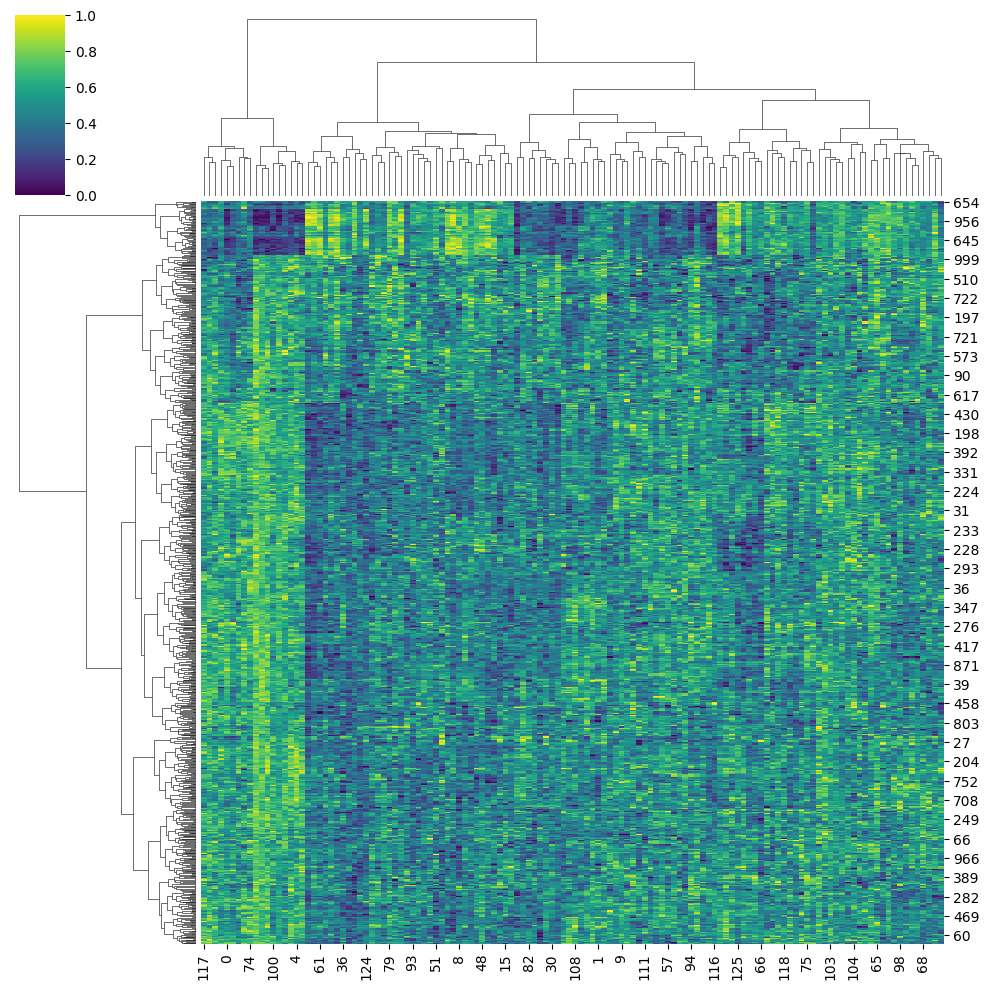

In [18]:
from scipy.cluster.hierarchy import fcluster

# Example: transformer output reshaped for clustering
data = transformer_out[:-1].view(1000, 128).detach().numpy()

# Generate the clustermap (note: row_cluster=True by default)
g = sns.clustermap(data, metric="euclidean", method="ward", cmap="viridis", standard_scale=1)

# Extract the linkage matrix (dendrogram structure)
linkage_matrix = g.dendrogram_row.linkage

In [19]:
torch.sum(emb_diff_out[0], dim=0).detach().numpy().shape

(979,)

In [20]:
mse_df = pd.DataFrame({
    'Gene': genes,
    'Sum': torch.sum(emb_diff_out[0], dim=0).detach().numpy()
})
best_predicted_genes = mse_df.sort_values(by='Sum')

In [21]:
best_predicted_genes

,Gene,Sum
770,REG1A,-3.629566
739,PRSS2,-3.071733
625,MALAT1,-2.112483
247,CPB1,-1.986593
835,SPINK1,-1.598179
...,...,...
120,CCL20,0.146040
919,TTR,0.147543
390,GCG,0.147961
542,IRF3,0.155324
